In [193]:
using LinearAlgebra
using Plots
using Printf
gr()
Plots.GRBackend()
filename = ""

include("Optimisation.jl")
include("Parameterization.jl")
include("RaySolver.jl")
include("PlotRays.jl")


segment (generic function with 1 method)

Définition des paramètres de contrôle

In [194]:
controlx = [-3. -1.7 -1.5 -1.2 -0.7 -0.3 0. 0.3 0.7 1. 1.5 1.7 3.]
controly = [ 0. 0. 0. 0.1 0.5 0.3 0. 0.6 0.45 0.1 0. 0. 0. ] .+ 4.2
#controlx = [-1.5 -0.7 -0.3 0. 0.3 0.7  1.5]
#controly = [0.  0.5 0.2 0.1 0.7 0.45  0.] .+ 1.7
control = vcat(controlx, controly)
control0 = control

2×13 Matrix{Float64}:
 -3.0  -1.7  -1.5  -1.2  -0.7  -0.3  0.0  0.3  0.7   1.0  1.5  1.7  3.0
  4.2   4.2   4.2   4.3   4.7   4.5  4.2  4.8  4.65  4.3  4.2  4.2  4.2

In [195]:
#movingcontrol = vcat([0.  0.  0.], [1.  0. 1.])
movingcontrol = vcat(0. .* controlx , 0. .* controlx .+ 1.)
#movingcontrol[2,13] = 0.
#movingcontrol[2,1] = 0.
println(movingcontrol)

[-0.0 -0.0 -0.0 -0.0 -0.0 -0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0]


In [196]:
#Fonction coût écart à un point
# Jeu de rayons parallèles en entrée
Nray= 300
Nangle = 10
colors = Plots.palette(:turbo, Nangle +1)
FOV = 30 # en degrés
FOV = FOV * pi / 180.
diam = 0.5 #diamètre de la pupille
angles = [pi / 2. - FOV + 2 * FOV * k / Nangle for k in 0:Nangle]
#sources = (Ray(-1. + 2 * i / Nray, angle  ) for i in 0:Nray)  


11-element Vector{Float64}:
 1.0471975511965979
 1.1519173063162575
 1.2566370614359175
 1.3613568165555772
 1.4660765716752369
 1.5707963267948966
 1.6755160819145565
 1.7802358370342162
 1.8849555921538759
 1.9896753472735358
 2.0943951023931957

Rayons en entrée du système avant optimisation

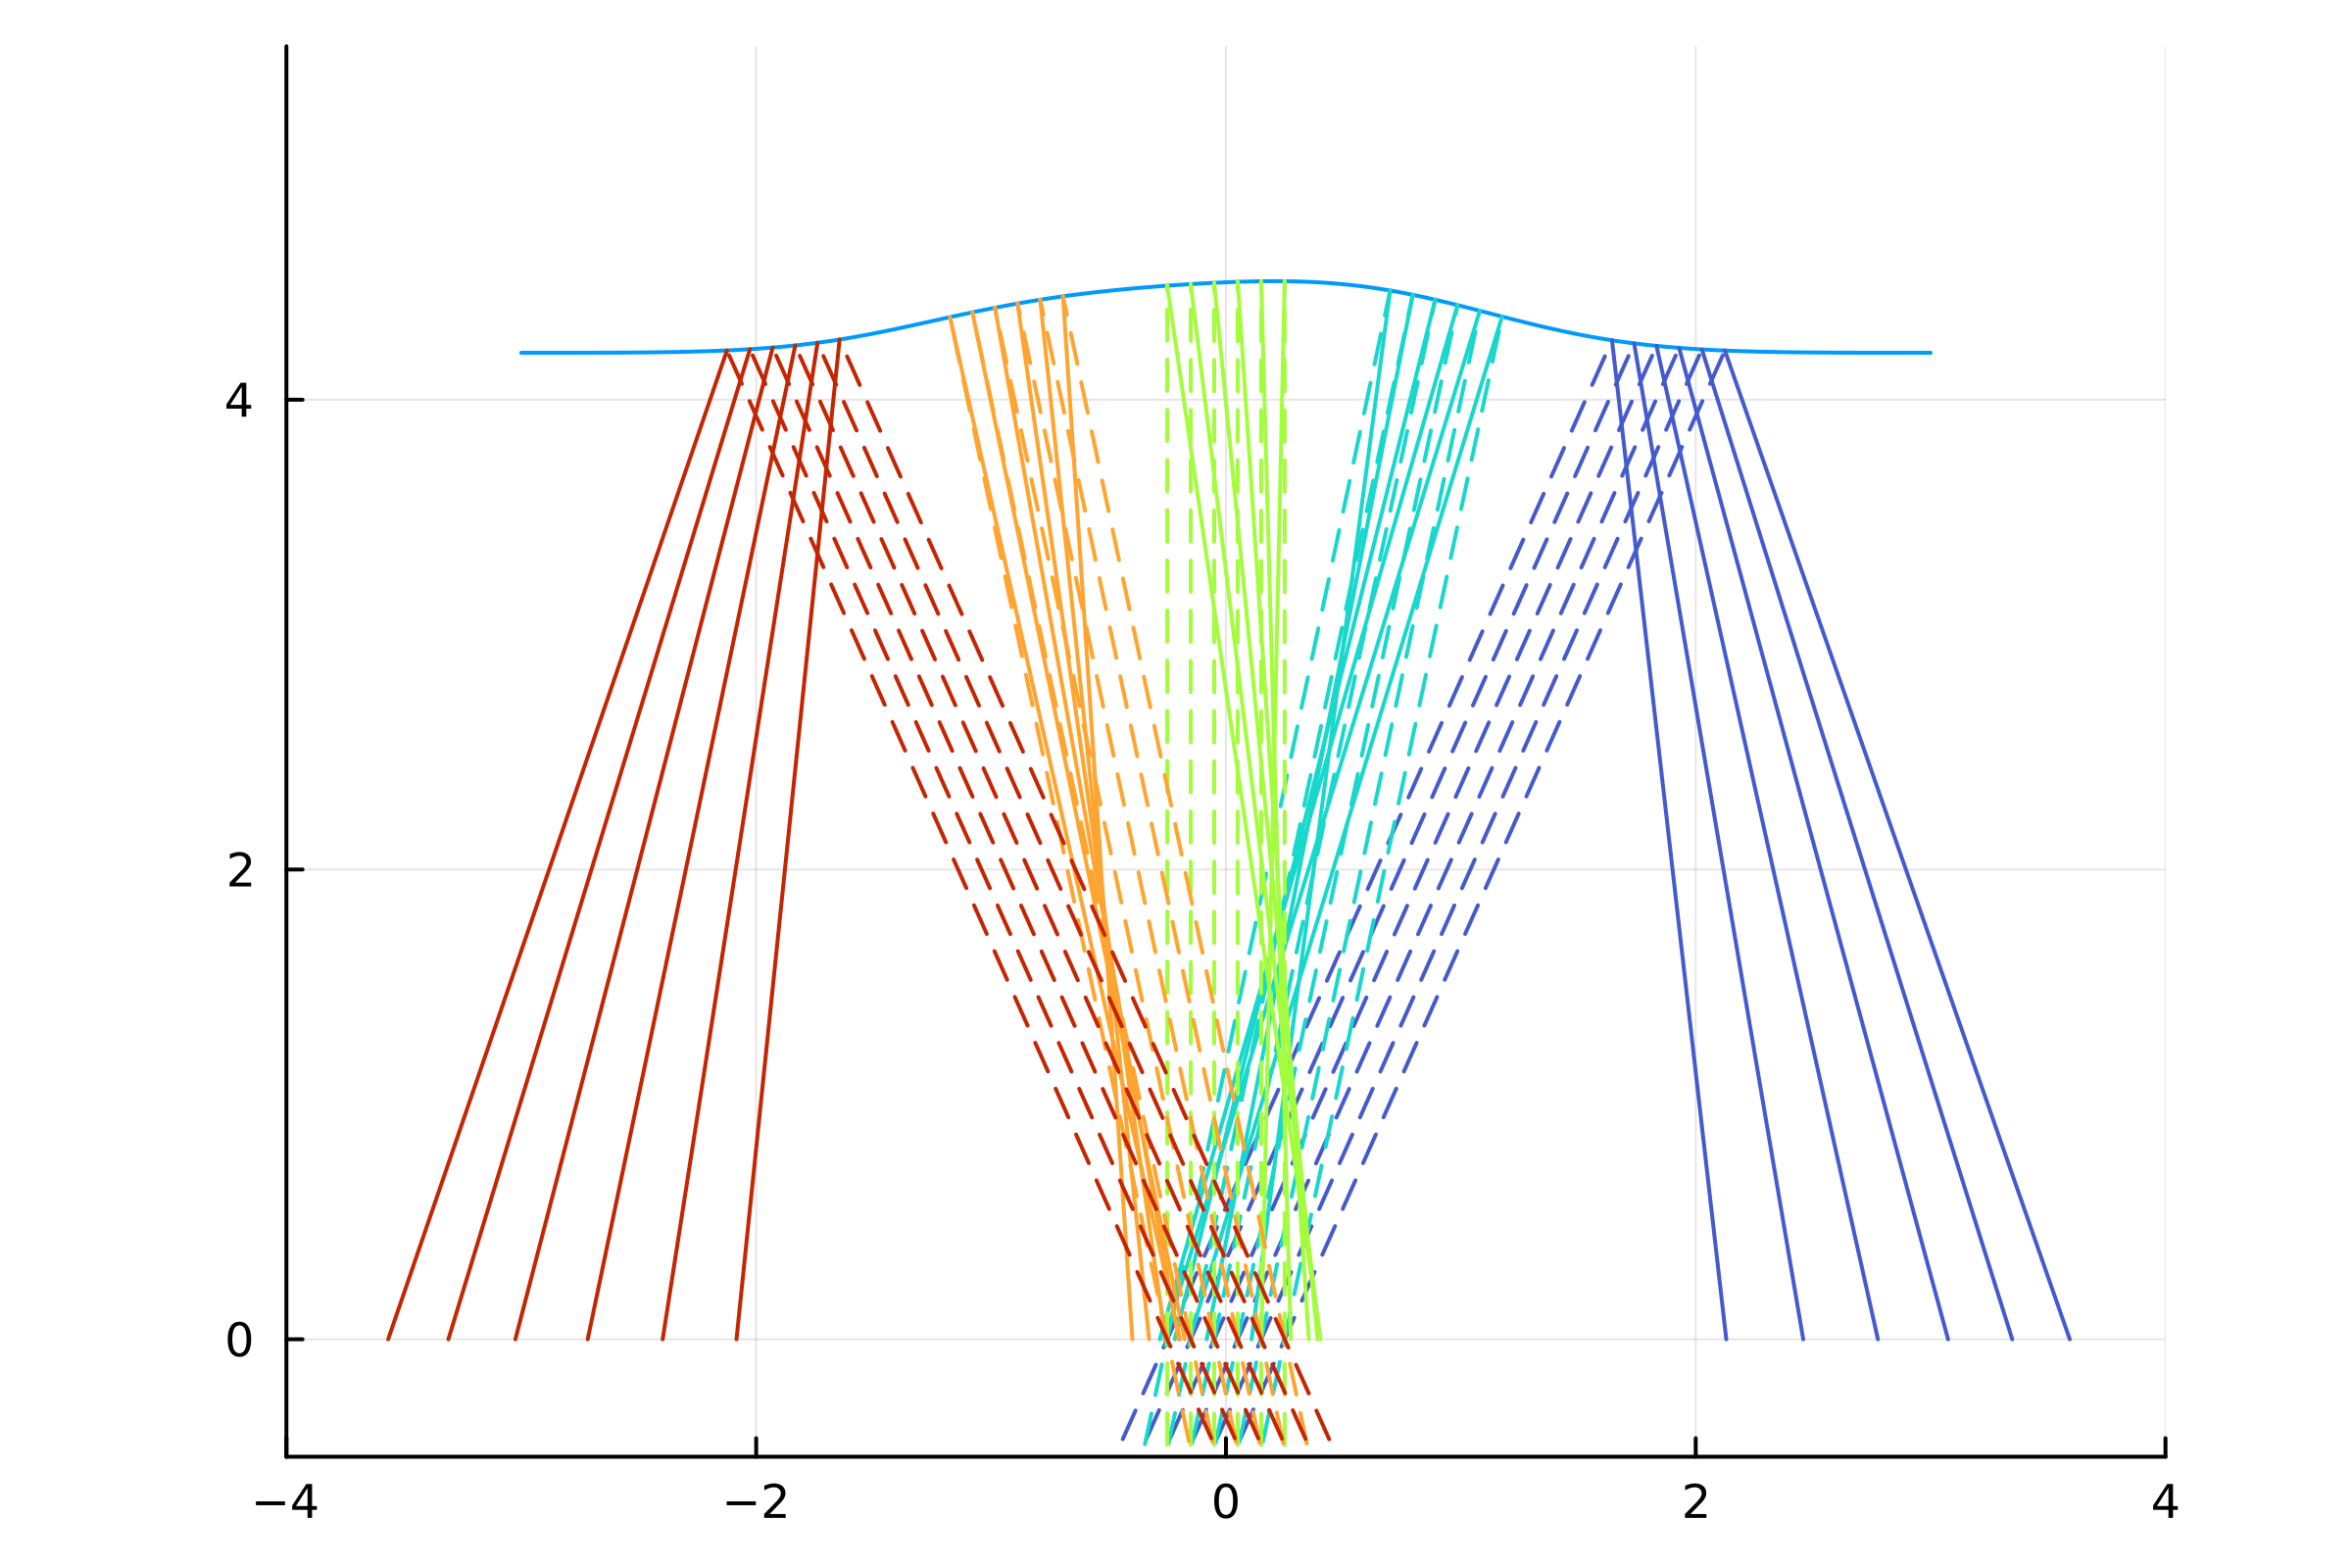

In [197]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( -0.5 , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = false, dpi = 400, yticks = 6)
for (k,angle) in enumerate(angles)
    if k%2 == 0
        source4plot = (Ray([-diam/2. + diam * i / 5, 0.], angle  ) for i in 0:5)  
        for ray in source4plot
            plot!(ray; choicecolor=colors[k], dashreflected = true)
        end
    end
end
savefig("init_rays_focal.png")
display(plt)

In [198]:
focal = 5
println(focal)
println("Le f-number est:", focal / diam)

5
Le f-number est:10.0


$$
j(\beta) = \mathbb{E}[ | [X_F]_1 - f[\Xi_S]_1|^2] = \frac{1}{N_{ray}} \sum_{i=1}^{N_{ray}} ( x_i(\beta) - f\cos(\theta_i))^2
$$

In [199]:
#Fonction coût
function cost0(control::Matrix{Float64})::Float64
    s = 0.
    for angle in angles
        source = (Ray([-diam/2. + diam * i / Nray, 0.], angle  ) for i in 0:Nray)  
        for ray in source
            s+= ( projectionplanfocal(billiard(control,ray) ).pos[1] - focal * cos(angle))^2.
        end
    end
    return s/ (Nray * Nangle)
end
cost0(control)

1.5262701353815207

Définition du coût

In [200]:
# Differentiel en x de la foinction cout sur le plan focal
function diffj0x(ray::Ray, cosangle::Float64)::Vector{Float64}
    return 2. * [ray.pos[1] - focal * cosangle, 0.]
end

# Differentiel en xi de la foinction cout sur le plan focal
function diffj0xi(ray::Ray)::Vector{Float64}
    return [0., 0.]
end

# Differentiel en x de la foinction cout sur le miroir
function jtildex(ray::Ray, cosangle::Float64)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalx(ray, diffj0x(rayf,cosangle), diffj0xi(rayf))
end

# Differentiel en xi de la foinction cout sur le miroir
function jtildexi(ray::Ray,cosangle::Float64)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalxi(ray, diffj0x(rayf,cosangle), diffj0xi(rayf))
end



jtildexi (generic function with 1 method)

In [201]:
function cross2d(vec1::Vector{Float64}, vec2::Vector{Float64})::Real
    return vec1[1]* vec2[2] - vec1[2]* vec2[1] 
end
cross2d([0.,1.], [1.,0.])

-1.0

Définition du gradient

In [202]:
#### fusionner jtilde
### fusionner projection focal (matrice par bloc ? utiliser strcture de julia)
function gradientj0(control::Matrix{Float64})::Tuple{Matrix{Float64},Symmetric{Float64,Matrix{Float64}}}
    n::Int64 = size(control)[2] - 1  # Degree of the Béziers curve  
    gradient::Matrix{Float64} = zeros(2,n+1)
    dr2 = zeros(2*(n+1), 2*(n+1))
    for angle in angles
        source = (Ray([-diam/2. + diam * i / Nray, 0.], angle  ) for i in 0:Nray) 
        for ray in source
            # on projette sur le miroir et on récupère le $t$ de param
            t::Float64 = intersectionLine(control, ray) 
            dic = geometricquantities(control, t)
            theta = ray.angle
            #prendre un dangle et une normale sortante et renvoie l'angle correspondant au rayon réfléchi
            sdotn = dic["normal"][1] * cos(theta) + dic["normal"][2] * sin(theta)
            sdott = dic["utangent"][1] * cos(theta) + dic["utangent"][2] * sin(theta)
            thetaf = atan( sin(theta) - 2. * sdotn * dic["normal"][2], cos(theta) - 2. * sdotn * dic["normal"][1] )
            #on calcule les termes de la dérivée de formes
            sderterm = shapederivativeterms(control, t) #termes de la dérivée de formes
            rayr = Ray(dic["point"], thetaf)
            djx = jtildex(rayr,cos(angle))
            djxi = jtildexi(rayr,cos(angle))
            gradient += dot(dic["normal"], djx ) .*  sderterm["thetan"]
            gradient +=  ( sderterm["thetanprime"] * cross2d(dic["normal"], dic["utangent"]) .-  sderterm["thetan"] .* (dic["curvature"] * cross2d(dic["normal"], [cos(thetaf), sin(thetaf)]) / dot([cos(thetaf), sin(thetaf) ], dic["normal"])   ) ) * cross2d(djxi, [cos(thetaf), sin(thetaf)])
                    #calculer terme ordre 2 pour LBMQ
            d::Float64 = norm( projectionplanfocal(billiard(control,ray) ).pos - dic["point"] )
            xi::Vector{Float64} = [cos(theta) ; sin(theta)]
            xif::Vector{Float64} = [cos(thetaf);sin(thetaf)]
            dxi::Vector{Float64} =  sdotn .* dic["utangent"] .+ sdott .* dic["normal"] 
            #Ici c'est mal calculé 
            
            k::Int64 = 2* (n+1)
            ci::Int64 = 0
            li::Int64 = 0
            cj::Int64 = 0
            lj::Int64 = 0
            for i in 1:k
                ci = (i <= (n+1) ) * 1 + (i > (n+1) ) * 2
                li = (i <= (n+1) ) * i + (i > (n+1) ) * (i - (n+1) ) 
                ei = basiscontrol( n+1, ci, li  )
                for j in i:k
                    cj = (j <= (n+1) ) * 1 + (j > (n+1) ) * 2
                    lj = (j <= (n+1) ) * j + (j > (n+1) ) * (j -(n+1)) 
                    if (movingcontrol[ci,li] != 0.)&&(movingcontrol[cj,lj] !=  0.)
                        ej = basiscontrol( n+1, cj , lj )
                        dx1::Vector{Float64} = dot(sderterm["thetan"], ei) .* xi ./ sdotn #  DB_1 ei
                        dxi1 = 2. .*  ( dot(  sderterm["thetanprime"]  .+ dic["curvature"] .* (sdott /sdotn) .* sderterm["thetan"] , ei)  ) .* dxi #  DB_2 ei
                        dri = jacimpactpoint(d , dic["point"] , xif,  dx1, dxi1)[1] #  Dxf ei
                        
                        dx2::Vector{Float64}  = dot(sderterm["thetan"], ej) .* xi ./ sdotn #  DB_1 ej
                        dxi2 = 2. .* ( dot(   sderterm["thetanprime"]  .+ dic["curvature"] .* (sdott /sdotn)  .*sderterm["thetan"] , ej)  ) .* dxi #  DB_2 ej
                        drj = jacimpactpoint(d , dic["point"] , xif,  dx2, dxi2)[1] #   Dxf ej
                        
                        dr2[i,j] += 2. * dri * drj
                        #Ça c'est la vrai matrice comme si tous les points bougaient.
                    end
                end
            end
            #on peut simplifier l'étape suivante 
            for i in 1:k 
                ci = (i <= (n+1) ) * 1 + (i > (n+1) ) * 2
                li = (i <= (n+1) ) * i + (i > (n+1) ) * (i - (n+1) ) 
                if (movingcontrol[ci,li] == 0.)
                        dr2[i,i] = length(source) * length(angles)
                end
            end
        end
    end
    return ( 2. * gradient ./ (Nray * Nangle), Symmetric( dr2  ./ (Nray * Nangle) ) )
end


function proj1(dj::Matrix{Float64})::Matrix{Float64}
    return movingcontrol .* dj 
end

    

proj1 (generic function with 1 method)

Test du gradient contre des différences finies

In [203]:
Niter = 150
step = 100.
gradientj0(control)

([0.19601814462547565 0.3496967574163524 … -0.4275657284209815 -0.227106425780543; 4.267033907866114 -1.8814131745970135 … -2.164795051244478 4.136082888051772], [1.1036666666666666 0.0 … 0.0 0.0; 0.0 1.1036666666666666 … 0.0 0.0; … ; 0.0 0.0 … 6.077577530310527 -2.2254299317890442; 0.0 0.0 … -2.2254299317890442 19.162513144259137])

In [204]:
iter=Vector{Float64}(undef, 0)
cost=Vector{Float64}(undef, 0)
@elapsed control= LMdescent(cost0, gradientj0, control, norm, proj1, step, true, Niter)

Iteration number : 0
Le lambda est :0.002
La plus petite valeur propre est :6.56787119668689e-5
Iteration number : 1
Le lambda est :0.0004
La plus petite valeur propre est :3.993639146357993e-5
Iteration number : 2
Le lambda est :8.0e-5
La plus petite valeur propre est :4.435996912892251e-5
Iteration number : 3
Le lambda est :1.6000000000000003e-5
La plus petite valeur propre est :5.569589199529906e-5
Iteration number : 4
Le lambda est :3.2000000000000007e-6
La plus petite valeur propre est :7.720192913949415e-5
Iteration number : 5
Le lambda est :6.400000000000001e-7
La plus petite valeur propre est :9.066384023101866e-5
Iteration number : 6
Le lambda est :1.2800000000000003e-7
La plus petite valeur propre est :9.26837126110409e-5
Iteration number : 7
Le lambda est :2.5600000000000008e-8
La plus petite valeur propre est :9.274334982683588e-5
Iteration number : 8
Le lambda est :1.0240000000000003e-8
La plus petite valeur propre est :9.274356832166903e-5
Iteration number : 9
Le lambda e

10.032987667

In [205]:
cost0(control)

6.379058483962965e-6

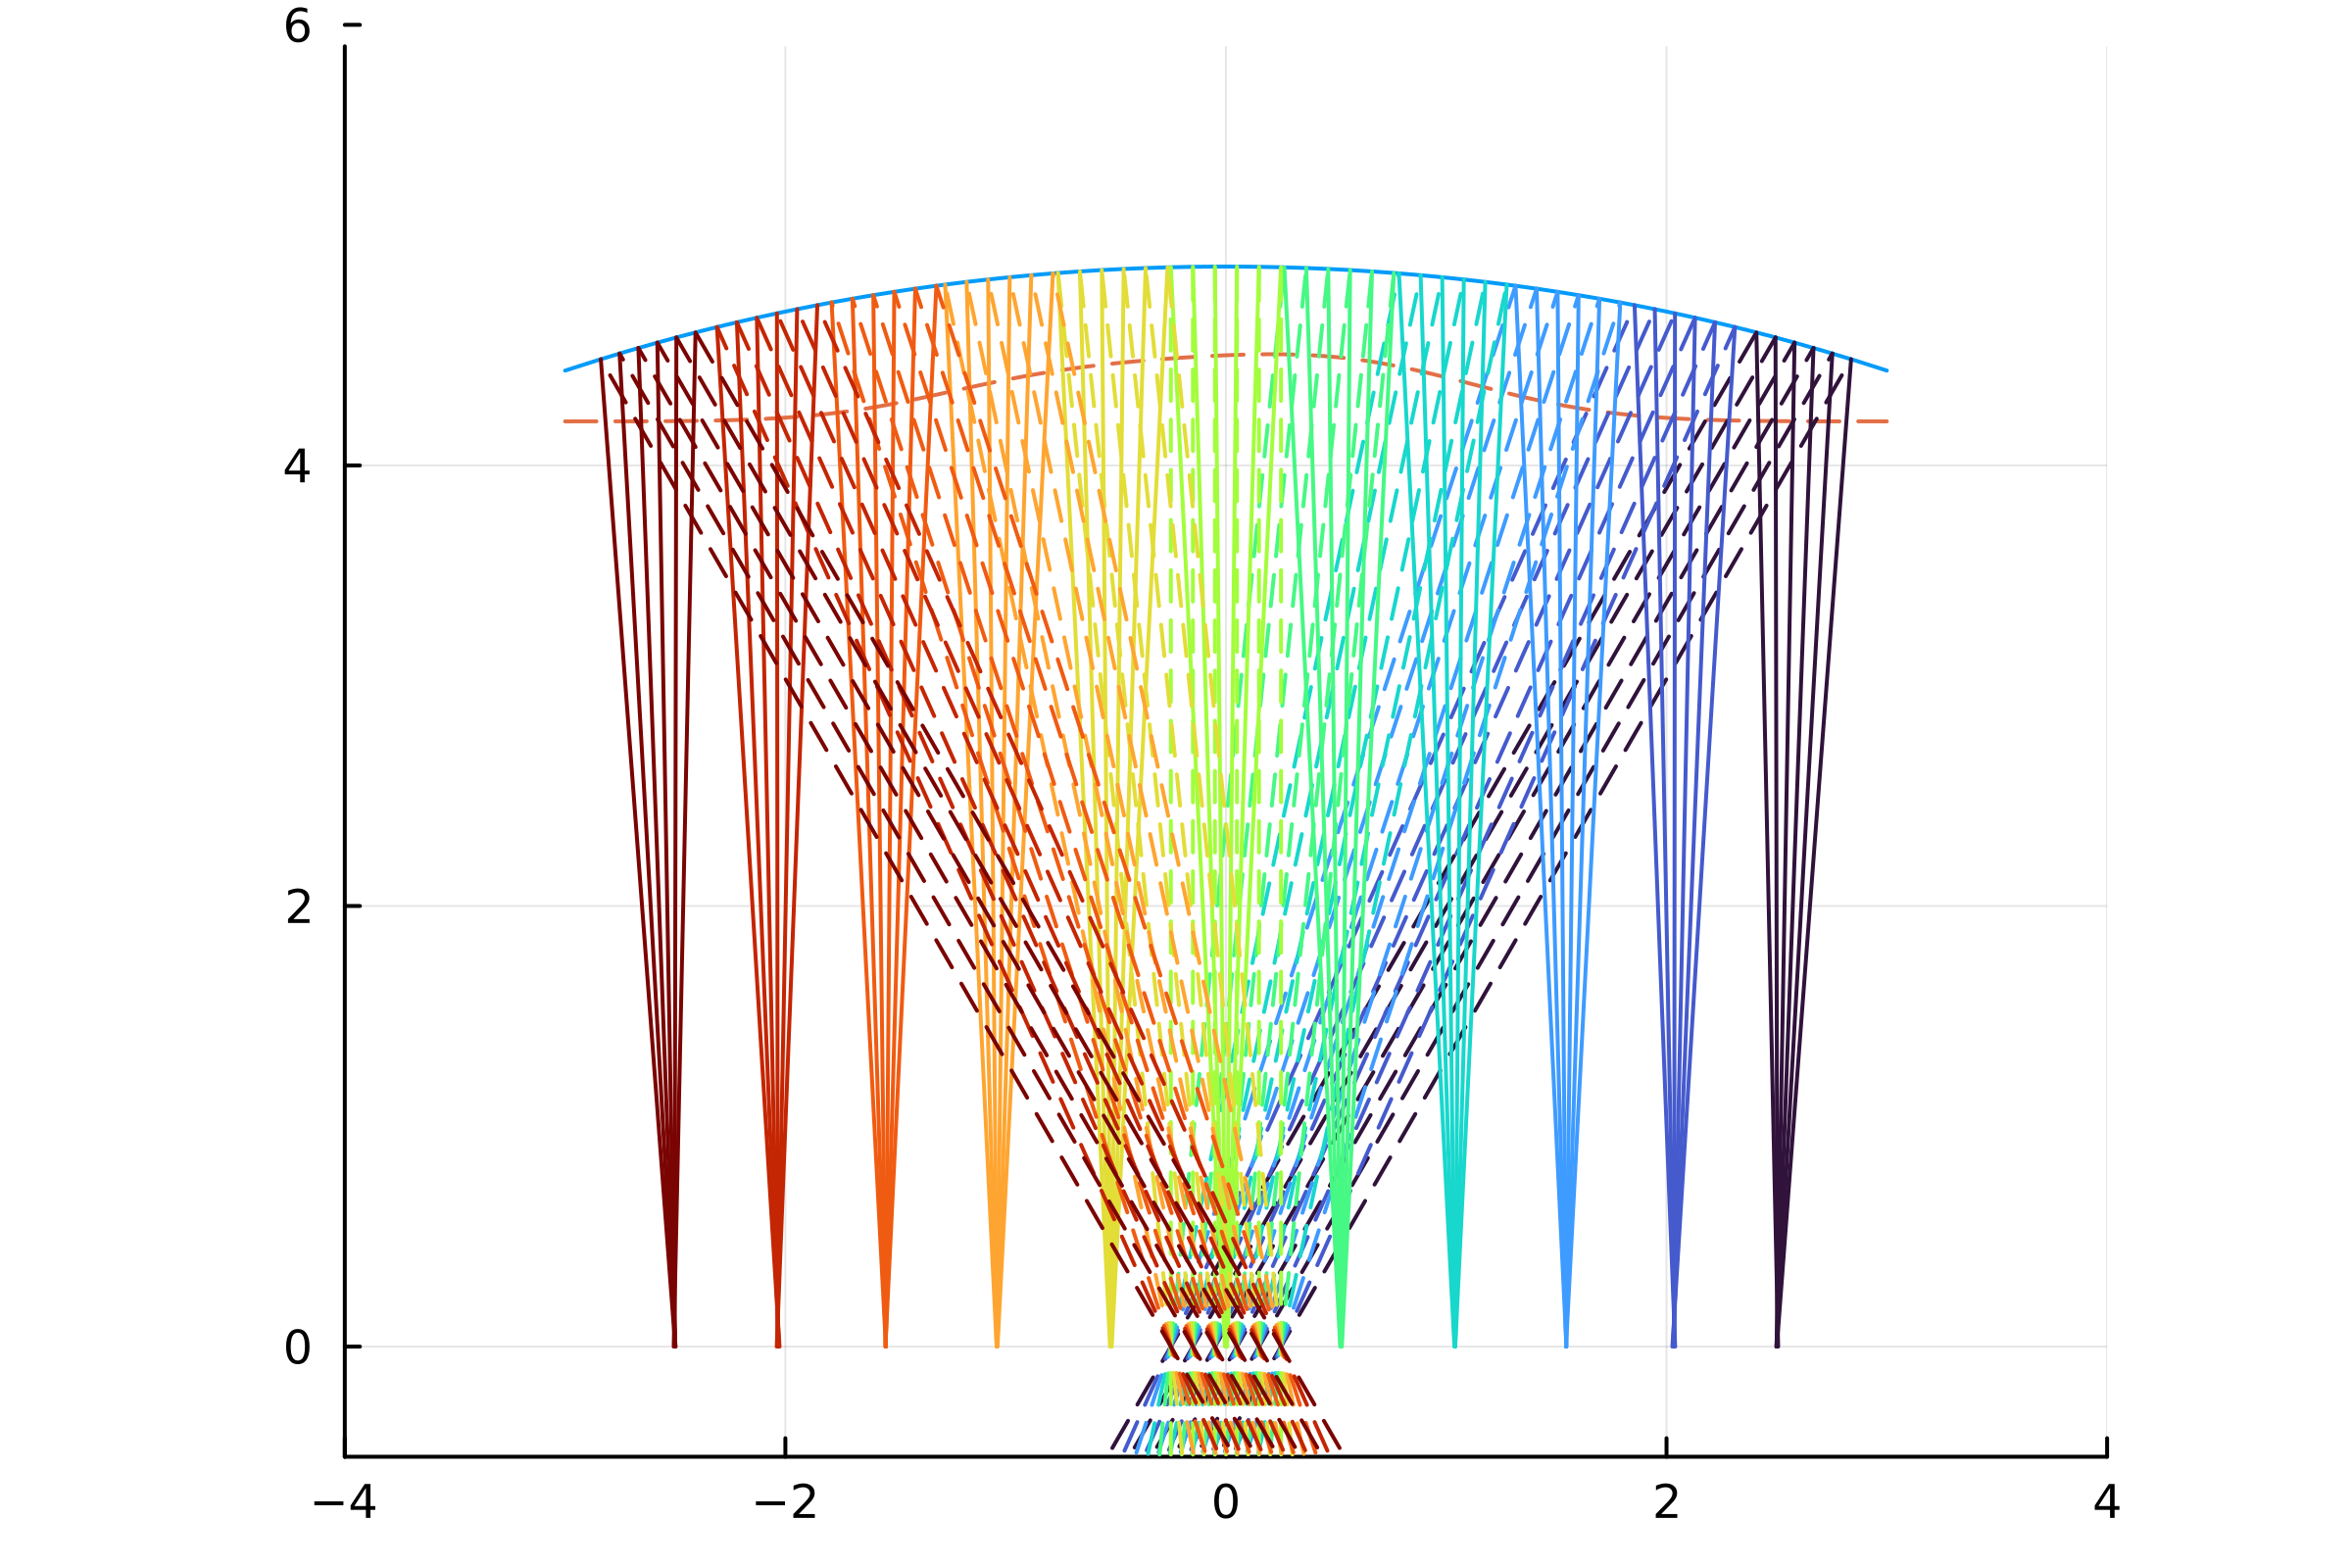

In [206]:
points = bezier(control, 0.)
points0 = bezier(control0, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
    points0 = hcat( points0, bezier(control0,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1., maximum( points[1,:] ) +1. )
ylim =  ( - 0.5, maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = false, dpi = 400, yticks = 6)
plot!(points0[1,:],points0[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = false, linestyle=:dash)
for (k,angle) in enumerate(angles)
    # si on veut afficher un rayon sur deux
    #if k%2 == 0
        #source4plot = (Ray([-0.5 + i / 5, 0.], angle  ) for i in 0:5)  
        #for ray in source4plot
            #plot!(ray; choicecolor=colors[k], dashreflected = true)
        #end
    #end
    # si on veut afficher tous les rayons
    source4plot = (Ray([-diam/2. + diam * i / 5, 0.], angle  ) for i in 0:5)  
    for ray in source4plot
        plot!(ray; choicecolor=colors[k], dashreflected = true)
    end
end
savefig("focal_optim_final_rays_LVBM.png")
display(plt)

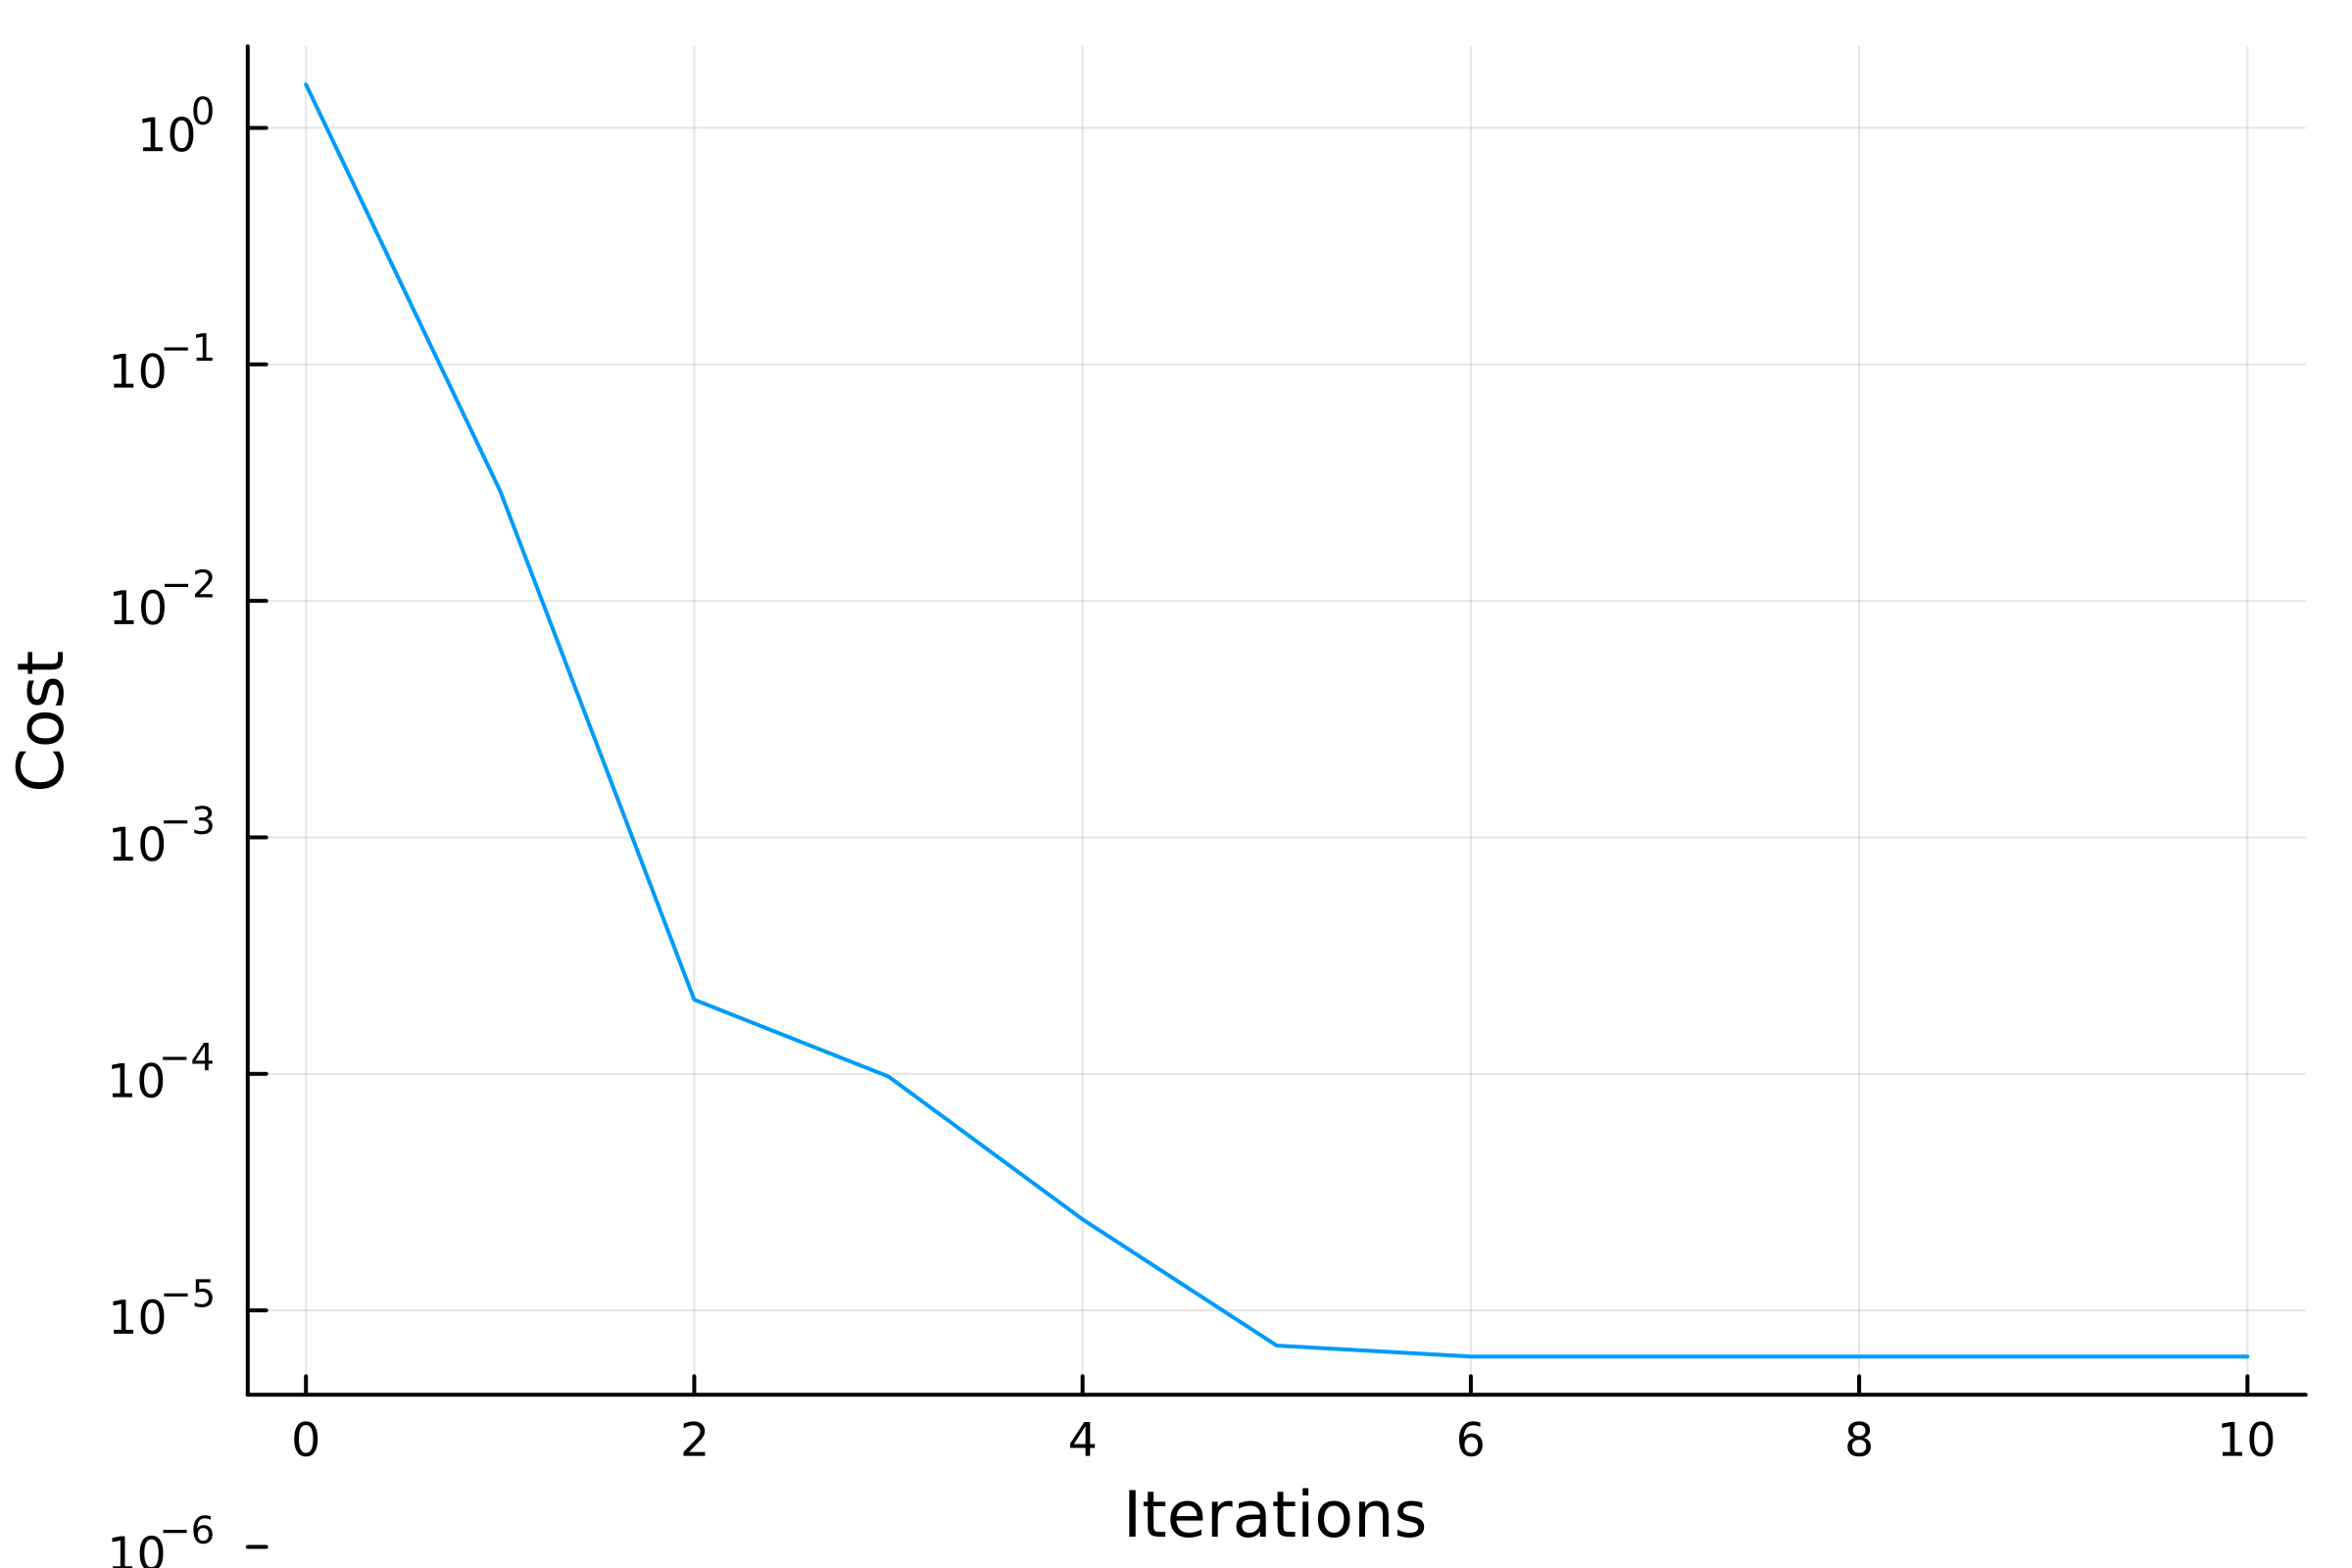

In [207]:
plt = plot(iter,cost, dpi = 400, yaxis =:log , legend = false, xlabel = "Iterations", ylabel = "Cost", xticks = 10, yticks = 10)
savefig("convergence_history_focal_LVBM.png")
display(plt)

Résultats de l'optimisation

Position des rayons sur le plan focal en fonction de l'angle d'entrée

In [208]:
collect(angles)

11-element Vector{Float64}:
 1.0471975511965979
 1.1519173063162575
 1.2566370614359175
 1.3613568165555772
 1.4660765716752369
 1.5707963267948966
 1.6755160819145565
 1.7802358370342162
 1.8849555921538759
 1.9896753472735358
 2.0943951023931957

In [209]:
function meanspot(control::Matrix{Float64},angle::Float64)::Float64
    s = 0.
    source = (Ray([-diam/2. + diam * i / Nray, 0.], angle  ) for i in 0:Nray)  
    for ray in source
        s+= projectionplanfocal(billiard(control,ray) ).pos[1]
    end
    return s/  Nray
end

function rmsspotradius(control::Matrix{Float64},angle::Float64)::Float64
    s = 0.
    source = (Ray([-diam/2. + diam * i / Nray, 0.], angle  ) for i in 0:Nray)  
    for ray in source
        s+= ( projectionplanfocal(billiard(control,ray) ).pos[1] - focal * cos(angle))^2.
    end
    return sqrt(s)/ Nray
end
#plot(segment(1.,1.),aspect_ratio=:equal,label = false)

rmsspotradius (generic function with 1 method)

60.00000000000001
Le point visé est 2.4999999999999996
Le point moyen est 2.5092989588870442
Le point moyen est 0.00014032784232895974
66.0
Le point visé est 2.033683215379001
Le point moyen est 2.0400839931853216
Le point moyen est 0.0002166332105661902
72.00000000000001
Le point visé est 1.5450849718747364
Le point moyen est 1.549434633808054
Le point moyen est 5.6145868629481066e-5
78.0
Le point visé est 1.039558454088796
Le point moyen est 1.0428098316317322
Le point moyen est 6.850110052947632e-5
84.0
Le point visé est 0.5226423163382673
Le point moyen est 0.5239883908740408
Le point moyen est 0.0001245249597452547
90.0
Le point visé est 3.061616997868383e-16
Le point moyen est 3.407114391157336e-5
Le point moyen est 0.00017216184864149268
96.0
Le point visé est -0.5226423163382677
Le point moyen est -0.5240678342988334
Le point moyen est 0.00012391768715289554
102.0
Le point visé est -1.0395584540887968
Le point moyen est -1.0427208152256344
Le point moyen est 7.197344149213886e-

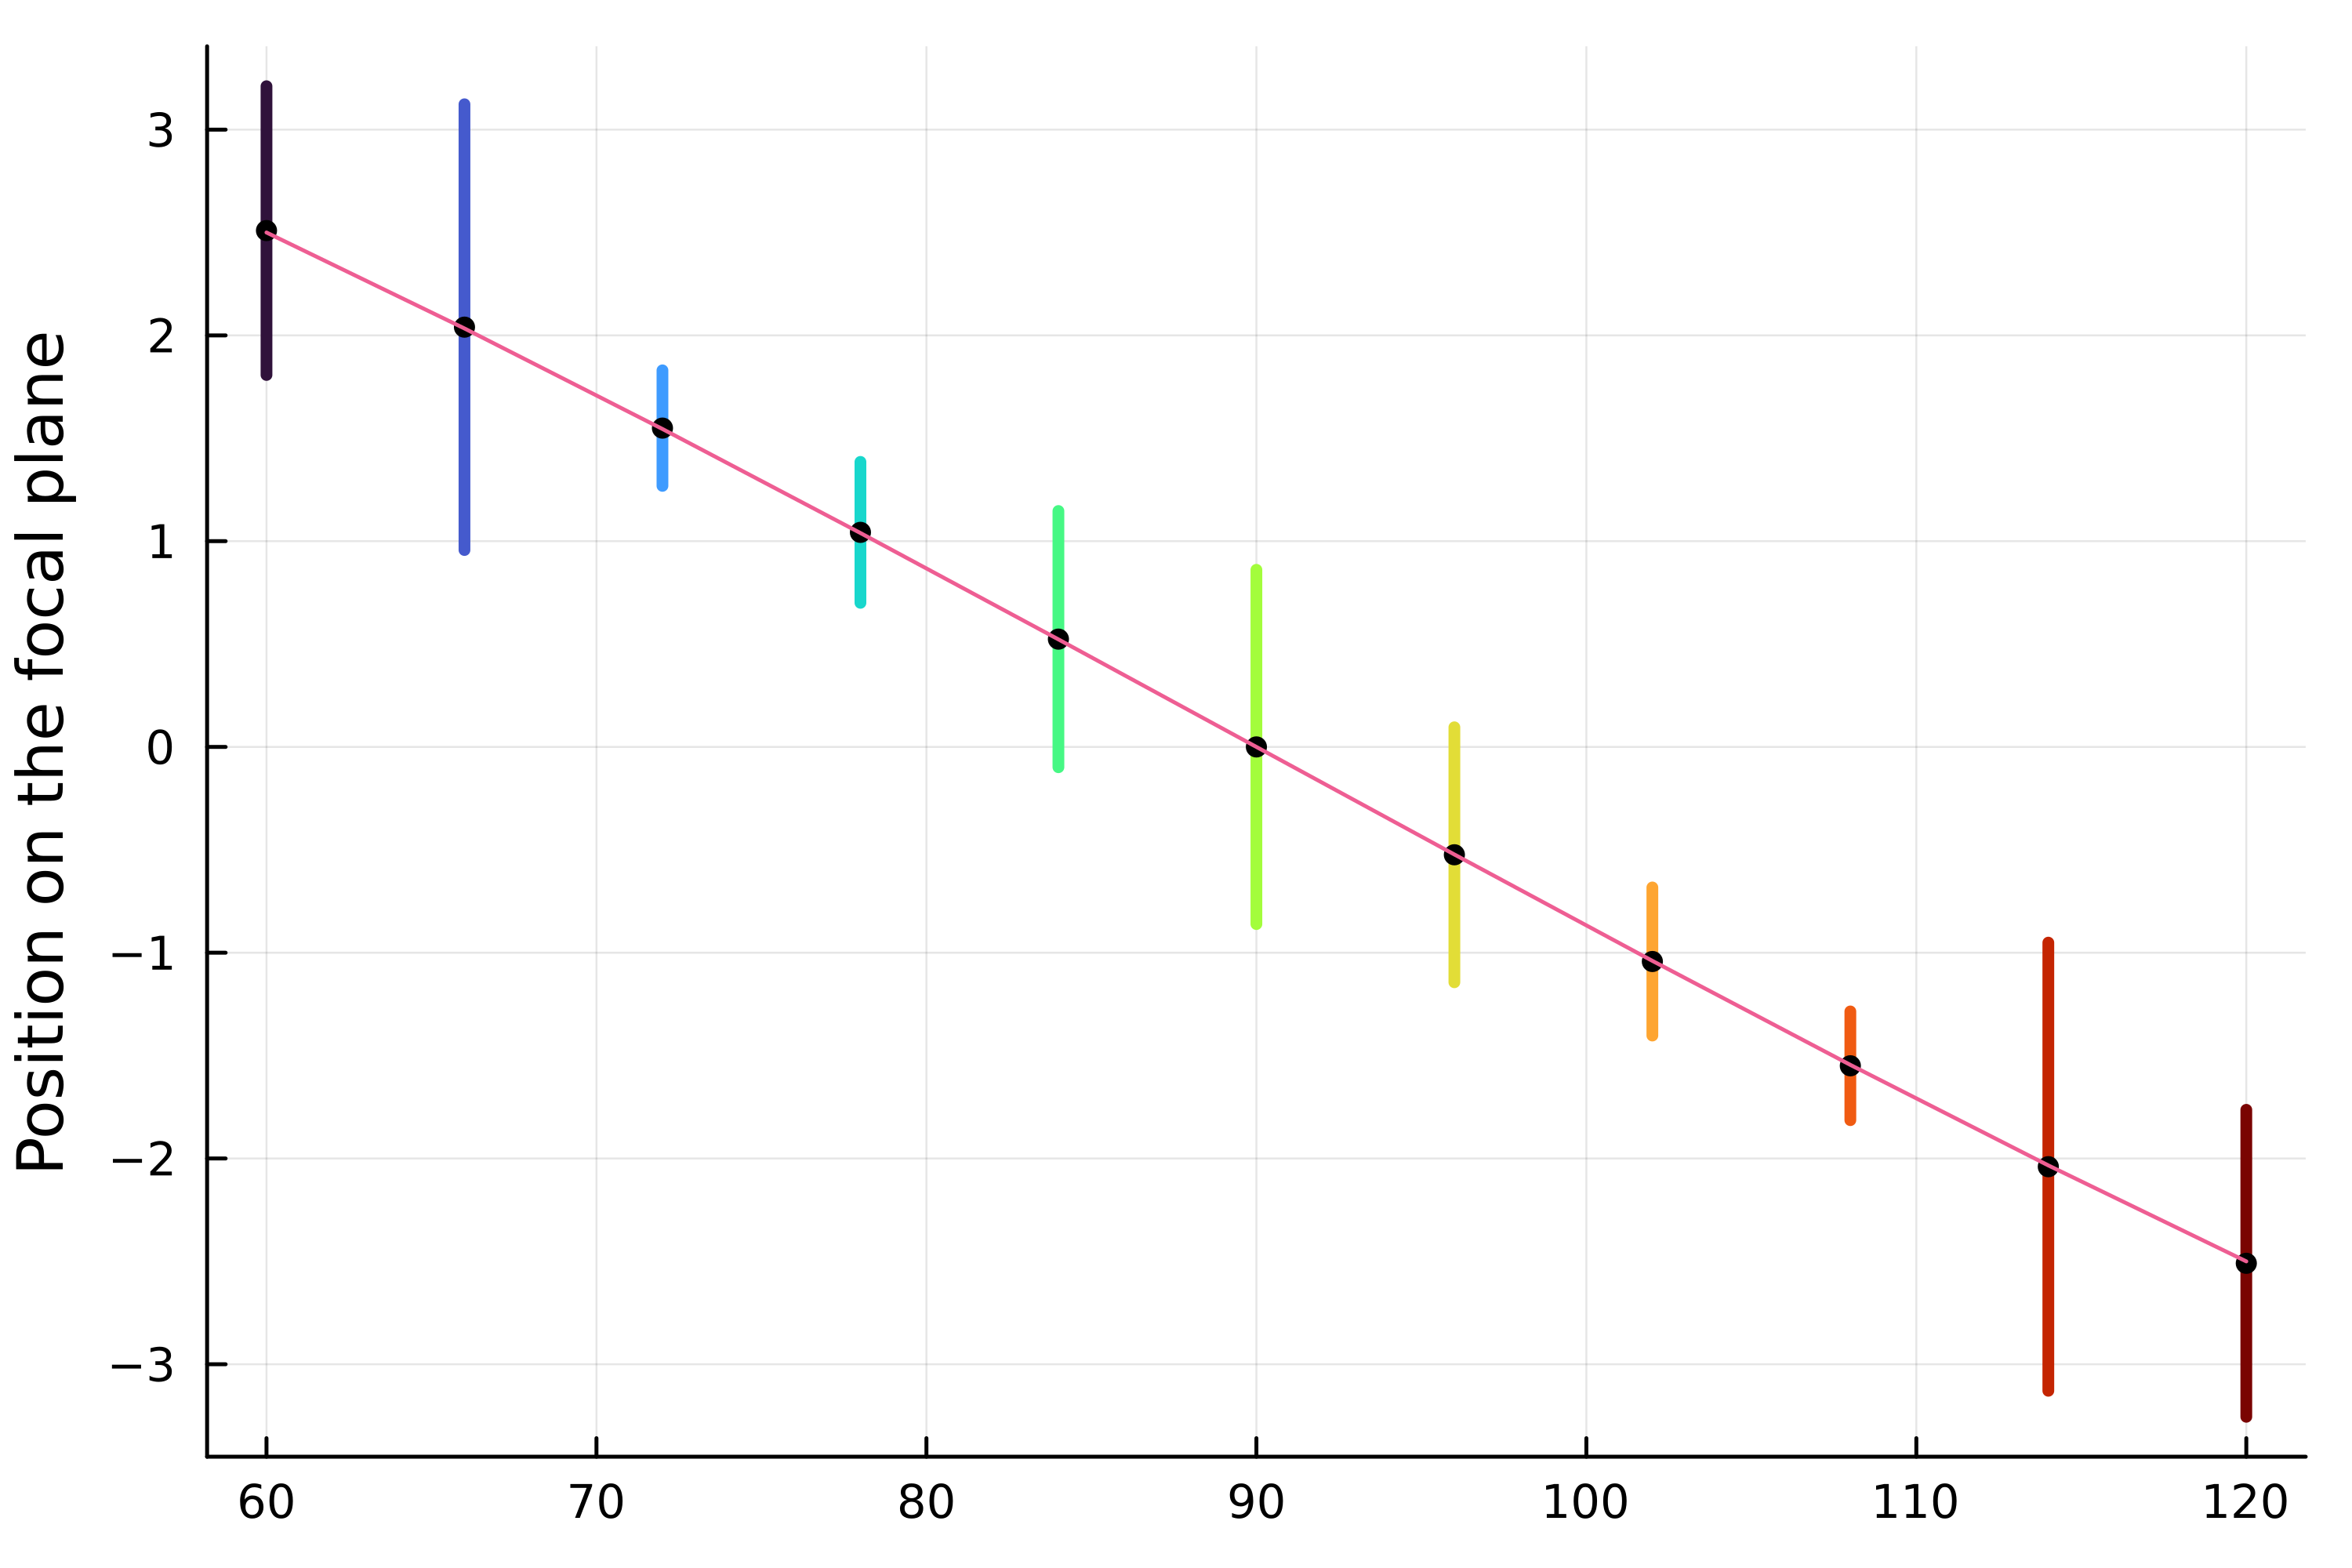

In [212]:
N = length(angles)
lw = 3.
mk = 3.
scaling = 5000.
for (k,angle) in enumerate(angles)
    if k == 1
        centrek  = meanspot(control,angle)
        rmsk = rmsspotradius(control,angle)
        println(180. * angle / pi)
        println("Le point visé est ", focal * cos(angle))
        println("Le point moyen est ", centrek)
        println("Le point moyen est ", rmsk)
        plt = plot(segment(180. * angle / pi, centrek,  scaling * rmsk), label = false, color = colors[k],linewidth = lw, dpi = 500, xticks =10) 
        scatter!( [180. * angle / pi] , [centrek] , label = false, color = :black,linewidth = lw, markersize = mk)
    else
        centrek  = meanspot(control,angle)
        rmsk = rmsspotradius(control,angle)
        println(180. * angle / pi)
        println("Le point visé est ", focal * cos(angle))
        println("Le point moyen est ", centrek)
        println("Le point moyen est ", rmsk)
        plot!(segment(180. * angle / pi, centrek,  scaling * rmsk), label = false, color = colors[k],linewidth = lw) 
        scatter!( [180. * angle / pi] , [centrek] , label = false, color = :black,linewidth = lw, markersize = mk)
    end
end

plot!( 180 .* angles ./ pi, focal .* cos.(angles), label = false, ylabel = "Position on the focal plane" )
savefig("dispersion_points_focal_LVBM.png")
display(plt)